# Nutri Score Analysis

The focus of this analysis lies on the OpenFoodFacts products which Nutri Scores.

Nutri Score differentiates food categories:

- General Food
  - Red Meat
  - Cheese
- Fats, Nuts, Legumes
- Beverages
  - Water

Data used: jsonl.gz dataset (from March 17 2025).

## Download jsonl.gz snapshot

This will take a couple of minutes

In [1]:
%%time
%%bash
if [ ! -f "openfoodfacts-products.jsonl.gz" ]; then
    curl -L -O https://static.openfoodfacts.org/data/openfoodfacts-products.jsonl.gz;
else
    echo "file already exists. skipping download";
fi

file already exists. skipping download
CPU times: user 3.17 ms, sys: 7.85 ms, total: 11 ms
Wall time: 9.87 ms


## Data Extraction - DuckDB

```sql
COPY (
  WITH data AS (
    SELECT *
    FROM read_ndjson(
      'openfoodfacts-products.jsonl.gz', ignore_errors=True,
      columns={
        code:'VARCHAR',
        nutriscore_version:'VARCHAR',
        nutriscore_grade:'VARCHAR',
        nutriscore_score:'INTEGER',
        -- nutriscore_data
        nutriscore:'STRUCT(
          "2023" STRUCT(
            category_available INTEGER,
            data STRUCT(
              count_proteins INTEGER,
              count_proteins_reason VARCHAR,
              is_beverage BOOLEAN,
              is_cheese BOOLEAN,
              is_fat_oil_nuts_seeds BOOLEAN,
              is_red_meat_product BOOLEAN,
              is_water BOOLEAN,
              negative_points INTEGER,
              negative_points_max INTEGER,
              positive_points INTEGER,
              positive_points_max INTEGER
            ),
            grade VARCHAR,
            nutrients_available INTEGER,
            nutriscore_applicable INTEGER,
            nutriscore_computed INTEGER,
            score INTEGER
          )
        )',
        nutriscore_data:'STRUCT(
          count_proteins INTEGER,
          count_proteins_reason VARCHAR,
          grade VARCHAR,
          is_beverage BOOLEAN,
          is_cheese BOOLEAN,
          is_fat_oil_nuts_seeds BOOLEAN,
          is_red_meat_product BOOLEAN,
          is_water BOOLEAN,
          negative_points INTEGER,
          negative_points_max INTEGER,
          positive_points INTEGER,
          positive_points_max INTEGER,
          score INTEGER
        )'
      }
    )
  )
  SELECT
    code,
    nutriscore_version,
    nutriscore_grade,
    nutriscore_score,
    nutriscore_data,
    to_json(nutriscore->'2023') AS nutriscore_2023
  FROM data
) TO 'nutriscore_dd.csv.gz' (FORMAT CSV, HEADER, FORCE_QUOTE (code));
```

## Data Loading

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
file_path = "../data/nutriscore_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# convert json string to dict
df.nutriscore = df.nutriscore.fillna('null').map(json.loads)

# use Int64 for counts with NaN
for col in ['nutriscore_version', 'nutriscore_score']:
    df[col] = df[col].astype('Int64')

display(df)

,nutriscore_version,nutriscore_grade,nutriscore_score,nutriscore_data,nutriscore
code,,,,,
0000101209159,2023,e,25,"{'count_proteins': 0, 'count_proteins_reason':...","{'category_available': 1, 'data': {'count_prot..."
0000105000011,2023,unknown,<NA>,NaN,"{'category_available': 1, 'data': {'count_prot..."
0000105000042,2021,unknown,<NA>,NaN,"{'category_available': 1, 'data': {'count_prot..."
0000105000059,2023,unknown,<NA>,NaN,"{'category_available': 1, 'data': {'count_prot..."
0000105000073,2021,unknown,<NA>,NaN,"{'category_available': 0, 'data': {'count_prot..."
...,...,...,...,...,...
8718907242424,2023,unknown,<NA>,NaN,"{'category_available': 0, 'data': {'count_prot..."
0007405956277,2023,unknown,<NA>,NaN,"{'category_available': 0, 'data': {'count_prot..."
3760019590615,<NA>,NaN,<NA>,NaN,None


In [4]:
df.nutriscore.notna().value_counts()

nutriscore
True     3725082
False      28643
Name: count, dtype: int64

In [5]:
df.nutriscore_data.notna().value_counts()

nutriscore_data
False    2447908
True     1305817
Name: count, dtype: int64

In [6]:
counts = df.nutriscore_grade.value_counts(dropna=False)
counts.map("{:,}".format)

nutriscore_grade
unknown           2,419,362
e                   347,168
d                   309,875
c                   251,510
a                   171,416
b                   141,987
not-applicable       83,805
NaN                  28,602
Name: count, dtype: object

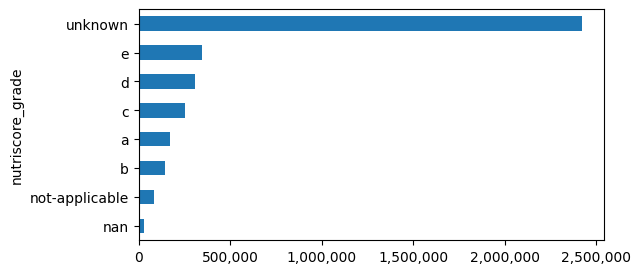

In [7]:
ax = counts.plot.barh(figsize=(6,3))
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
ax.invert_yaxis()

In [8]:
df.nutriscore_version.value_counts(dropna=False).map("{:,}".format)

nutriscore_version
2023    2,472,175
2021    1,252,907
<NA>       28,643
Name: count, dtype: object

In [9]:
df.nutriscore.dropna().map(lambda x: x['grade']).value_counts(dropna=False).map("{:,}".format)

nutriscore
unknown           2,419,387
e                   347,170
d                   309,859
c                   251,490
a                   171,400
b                   141,962
not-applicable       83,814
Name: count, dtype: object

In [10]:
# extract data as DataFrame
#data_df = pd.DataFrame.from_records(df.nutriscore.dropna().apply(lambda x: x['data']).values)

# get all keys starting with 'is_' and having a value of True
cats = df.nutriscore.apply(lambda x: ", ".join([k for k, v in x['data'].items() if k.startswith('is_') and v]) if x != None else None)

In [11]:
cats.value_counts(dropna=False).map("{:,}".format)

nutriscore
                                                         3,281,012
is_beverage                                                211,992
is_fat_oil_nuts_seeds                                       90,874
is_cheese                                                   74,590
is_red_meat_product                                         59,956
None                                                        28,643
is_beverage, is_water                                        5,816
is_cheese, is_red_meat_product                                 394
is_beverage, is_fat_oil_nuts_seeds                             201
is_fat_oil_nuts_seeds, is_red_meat_product                      85
is_cheese, is_fat_oil_nuts_seeds                                76
is_beverage, is_cheese                                          60
is_beverage, is_red_meat_product                                21
is_beverage, is_cheese, is_water                                 2
is_beverage, is_fat_oil_nuts_seeds, is_water       

### Plotting Function

In [12]:
nutricol = {
    'dark_green':  '#008f00',  # C=100, M=25, Y=100
    'lime_green':  '#56bf00',  # C=55,  M=25, Y=100
    'yellow':      '#FFCC00',  # M=20,  Y=100
    'orange':      '#FF6600',  # M=60,  Y=100
    'red':         '#FF1900',  # M=90,  Y=100
}

general_limits = [0, 2, 10, 18]
general_labels = ['A (<=0)', 'B (1-2)', 'C (3-10)', 'D (11-18)', 'E (>=19)']
fatoilnuts_limits = [-6, 2, 10, 18]
fatoilnuts_labels = ['A (<=-6)', 'B (-5-2)', 'C (3-10)', 'D (11-18)', 'E (>=19)']
beverage_limits = [-100, 2, 6, 9]
beverage_labels = ['A waters', 'B (<=2)', 'C (3-6)', 'D (7-9)', 'E (>=10)']
waters_limits = [0, 2, 6, 9]

def plot_nutri(scores: pd.Series, min: int, max: int, limits: list, colors: list, labels: list = None, title: str = None):
  bins = np.arange(min-0.5, max+0.51, 1)
  fig, ax = plt.subplots(figsize=(6,3.5))
  scores.dropna().plot.hist(bins=bins, ax=ax)
  
  ax.yaxis.set_major_formatter(lambda y, pos: f'{int(y):,}')
  ax.set_ylabel('# of Products')
  ax.set_xlabel('Score')
  ax.set_title(f"{title}\n({len(scores):,} products)")

  legend_handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
  ax.legend(handles=legend_handles, title='Nutri-Score', loc='upper right')

  # Iterate over each bar (patch) in the histogram
  for patch in ax.patches:
    # Get the left edge and width of the bin to calculate its center
    x = patch.get_x()
    width = patch.get_width()
    center = x + width / 2

    # iterate with index over limits
    for i, limit in enumerate(limits):
      if center <= limit:
        patch.set_facecolor(colors[i])
        break;
      else:
        patch.set_facecolor(colors[-1])

  # show min and max
  ax.axvline(min-0.5, color='grey', linestyle=':')
  ax.axvline(max+0.5, color='grey', linestyle=':')

  ax.annotate(f"min: {min}",
                  xytext=(0.01, -0.22), textcoords='axes fraction',
                  xy=(min-0.5, 0), xycoords='data',
                  size=9, va="center", ha="left",
                  bbox=dict(boxstyle="square", fc="w", pad=0.3),
                  arrowprops=dict(arrowstyle="->",
                                  connectionstyle="arc3,rad=0.2",
                                  fc="w"))
  ax.annotate(f"max: {max}",
                  xytext=(0.85, -0.22), textcoords='axes fraction',
                  xy=(max+0.5, 0), xycoords='data',
                  size=9, va="center", ha="left",
                  bbox=dict(boxstyle="square", fc="w", pad=0.3),
                  arrowprops=dict(arrowstyle="->",
                                  connectionstyle="arc3,rad=-0.2",
                                  fc="w"))
  plt.tight_layout()
  return fig

## Score Distribution

In [13]:
general_scores = df[cats.map(lambda x: -1 if x == None else len(x)) == 0].nutriscore_score
general_scores.describe()

count     910473.0
mean     12.011904
std      10.572237
min          -17.0
25%            3.0
50%           12.0
75%           20.0
max           55.0
Name: nutriscore_score, dtype: Float64

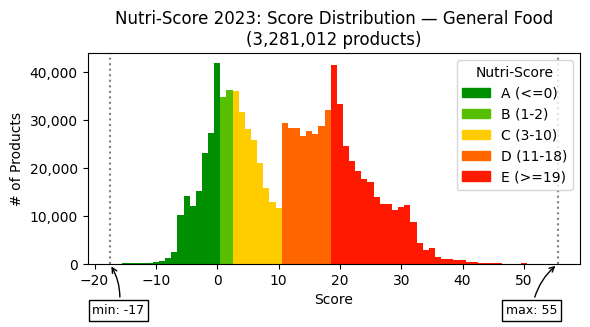

In [14]:
fig = plot_nutri(general_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — General Food')
fig.savefig("nutriscore_general.png")

In [15]:
# only is_cheese
cheese_scores = df[cats.eq('is_cheese')].nutriscore_score
cheese_scores.describe()

count      63755.0
mean     13.633958
std       5.087275
min           -8.0
25%           11.0
50%           14.0
75%           16.0
max           41.0
Name: nutriscore_score, dtype: Float64

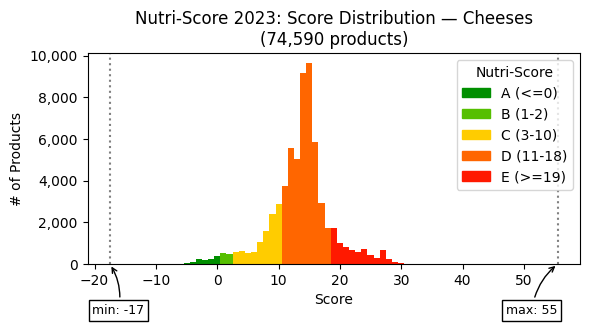

In [16]:
fig = plot_nutri(cheese_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — Cheeses')
fig.savefig("nutriscore_cheeses.png")

In [17]:
# only red meat products
redmeat_scores = df[cats.eq('is_red_meat_product')].nutriscore_score
redmeat_scores.describe()

count      48025.0
mean     15.952795
std       9.853466
min           -7.0
25%            7.0
50%           16.0
75%           23.0
max           48.0
Name: nutriscore_score, dtype: Float64

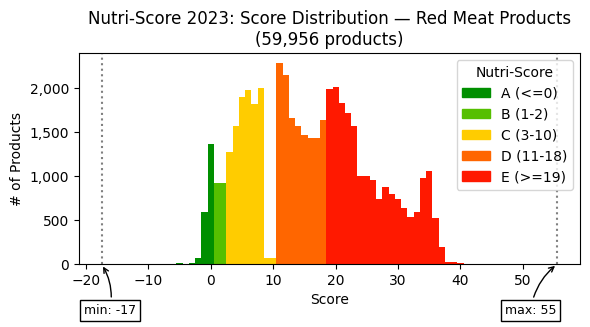

In [18]:
fig = plot_nutri(redmeat_scores, -17, 55, general_limits, list(nutricol.values()), general_labels, title='Nutri-Score 2023: Score Distribution — Red Meat Products')
fig.savefig("nutriscore_red_meat.png")

In [19]:
# only is_fat_oil_nuts_seeds
fatoilnuts_scores = df[cats.eq('is_fat_oil_nuts_seeds')].nutriscore_score
fatoilnuts_scores.describe()

count     73133.0
mean     3.301998
std       9.52525
min         -17.0
25%          -3.0
50%           1.0
75%           9.0
max          53.0
Name: nutriscore_score, dtype: Float64

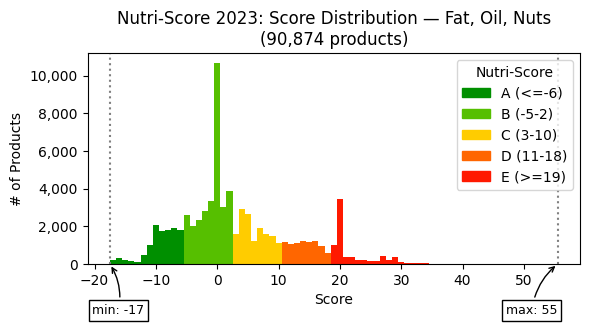

In [20]:
fig = plot_nutri(fatoilnuts_scores, -17, 55, fatoilnuts_limits, list(nutricol.values()), fatoilnuts_labels, title='Nutri-Score 2023: Score Distribution — Fat, Oil, Nuts')
fig.savefig("nutriscore_fatoilnuts.png")

In [21]:
# only beverages
beverage_scores = df[cats.eq('is_beverage')].nutriscore_score
beverage_scores.describe()

count    120025.0
mean     6.410848
std      6.541316
min         -18.0
25%           1.0
50%           5.0
75%          11.0
max          54.0
Name: nutriscore_score, dtype: Float64

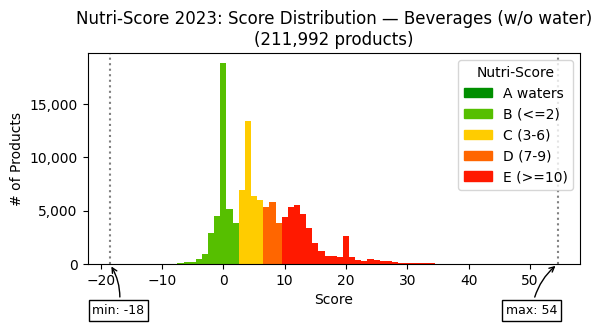

In [22]:
fig = plot_nutri(beverage_scores, -18, 54, beverage_limits, list(nutricol.values()), beverage_labels, title='Nutri-Score 2023: Score Distribution — Beverages (w/o water)')
fig.savefig("nutriscore_beverages.png")

In [23]:
# only water
water_scores = df[cats.eq('is_beverage, is_water')].nutriscore_score
water_scores.describe()

count      5799.0
mean     0.254009
std      1.876804
min          -7.0
25%           0.0
50%           0.0
75%           0.0
max          25.0
Name: nutriscore_score, dtype: Float64

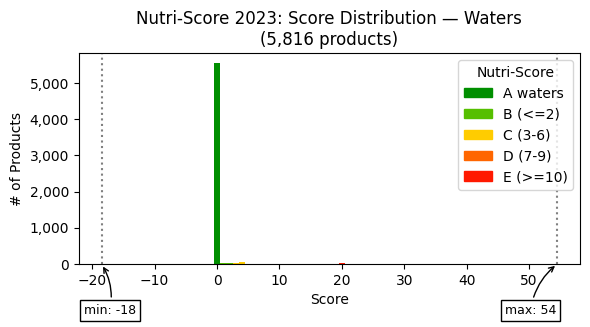

In [24]:
fig = plot_nutri(water_scores, -18, 54, waters_limits, list(nutricol.values()), beverage_labels, title='Nutri-Score 2023: Score Distribution — Waters')
fig.savefig("nutriscore_waters.png")